# Caso J · 03 Series temporales en InfluxDB para tráfico

> _Tutorial · Caso de uso: **J — Tráfico + YOLO** · Capa Medallion: **bronce → plata** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Tomar el mock `traffic_camera_mock.csv` y construir line protocol con los tags `domain_id=traffic_cameras`, `site_id=valencia`, `asset_id=DGT_CAM_*`.


## 2. Qué se aprende

- Mapping camera_id → asset_id.
- 3 variables: count / level / confidence.
- Por qué los conteos van como counter o analog_gauge.


## 3. Contexto del caso de uso

Plata para Caso J.


## 4. Relación con CENTINELA+

Independiente del aula.


## 5. Relación con Medallion

Bronce → plata.


## 6. Datos de entrada

Mock 7 días × 15 min × 2 cámaras.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

`vehicle_count` (analog_gauge), `congestion_level` (analog_gauge), `detection_confidence` (analog_gauge).


## 9. Carga de datos o mock

Cargamos.


In [2]:
csv_path = ROOT / "notebooks/_data/traffic_camera_mock.csv"
df = pd.read_csv(csv_path, comment="#", parse_dates=["timestamp"])
df.head()


,timestamp,camera_id,vehicle_count,congestion_level,detection_confidence,precip_mm
0,2024-09-01 00:00:00+00:00,DGT_CAM_V46_001,36,1,0.849,0.08
1,2024-09-01 00:15:00+00:00,DGT_CAM_V46_001,29,0,0.830,0.08
2,2024-09-01 00:30:00+00:00,DGT_CAM_V46_001,30,0,0.853,0.08
3,2024-09-01 00:45:00+00:00,DGT_CAM_V46_001,38,0,0.961,0.00
4,2024-09-01 01:00:00+00:00,DGT_CAM_V46_001,36,0,0.883,0.00


## 10. Exploración paso a paso

Resumen por cámara.


In [3]:
print(df.groupby("camera_id")["vehicle_count"].agg(["mean", "max"]).round(2))


                  mean  max
camera_id                  
DGT_CAM_V46_001  44.81  105
DGT_CAM_V46_002  67.85  126


## 11. Transformación bronce → plata

Generamos line protocol.


In [4]:
out_dir = ROOT / "output" / "case_J"
out_dir.mkdir(parents=True, exist_ok=True)
lines = []
for _, row in df.iterrows():
    ts_ns = int(pd.Timestamp(row["timestamp"]).value)
    for csv_col, var in [("vehicle_count", "vehicle_count"),
                          ("congestion_level", "congestion_level"),
                          ("detection_confidence", "detection_confidence")]:
        lines.append(build_line_protocol(
            measurement=MEASUREMENT_TELEMETRY,
            tags={"captia_env": "dev", "domain_id": "traffic_cameras",
                  "site_id": "valencia", "asset_id": row["camera_id"], "variable": var},
            fields={"value": float(row[csv_col])},
            timestamp_ns=ts_ns,
        ))
(out_dir / "traffic.lp").write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {len(lines)} líneas")


Wrote 4032 líneas


## 12. Construcción de capa oro

Notebook 04.


## 13. Visualizaciones explicativas

Conteo medio por hora.


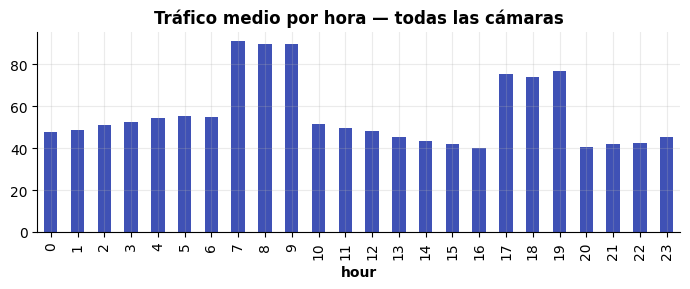

In [5]:
df["hour"] = df["timestamp"].dt.hour
df.groupby("hour")["vehicle_count"].mean().plot.bar(color="#3F51B5", figsize=(7, 3))
plt.title("Tráfico medio por hora — todas las cámaras"); plt.tight_layout()


## 14. Validaciones

Tags presentes y valor numérico.


In [6]:
sample = lines[0]
assert "domain_id=traffic_cameras" in sample
assert "value=" in sample
print("Sample:", sample)


Sample: captia_point,asset_id=DGT_CAM_V46_001,captia_env=dev,domain_id=traffic_cameras,site_id=valencia,variable=vehicle_count value=36.0 1725148800000000000


## 15. Errores comunes

1. Mezclar imágenes con line protocol.
2. Usar `vehicle_count` como bool (>50 → True): pierde granularidad.
3. Olvidar `congestion_level` como variable independiente.


## 16. Ejercicios propuestos

1. Calcula `dvc/dt` en 15 min.
2. Define una alerta `congestion_level == 3` durante 30 min.
3. Combina con AEMET (lluvia) — ya en `traffic_camera_mock.csv`.


## 17. Cómo se reutiliza con datos reales

Sustituir el mock por counts del notebook 02.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `10_case_J_traffic_yolo/04_integracion_meteo_trafico.ipynb`.
- Documento web del caso: `docs/use-cases/case-j-traffic-yolo.md`.


## 19. Marco teórico (nivel doctoral)

### YOLO v8 — single-stage anchor-free detector

Por cada celda de la grid, salida:

$$
\hat{y} = (b_x, b_y, b_w, b_h, p_{obj}, p_{c_1}, ..., p_{c_C})
$$

Loss combinada:

$$
\mathcal{L} = \lambda_{box} \mathcal{L}_{CIoU} + \lambda_{obj} \mathcal{L}_{BCE,obj} + \lambda_{cls} \mathcal{L}_{BCE,cls}
$$

### Series temporales tráfico

$$
N_v(t) = \sum_{i=1}^{D_t} \mathbb{1}[\text{detection}_i \in v_{ROI}]
$$

con NMS IoU threshold = 0.5.

### Predictor congestión

$$
\hat{C}(t+15) = \text{XGB}(N_v(t), N_v(t-15), ..., \text{weather}, t_{hora}, t_{dow})
$$

con $C \in \{0, 1, 2, 3\}$ niveles de congestión.

### Métricas

$$
\text{mAP}@0.5 = \frac{1}{|C|} \sum_{c \in C} \text{AP}_c \quad (\text{IoU} \geq 0.5)
$$

Objetivos: mAP@0.5 ≥ 0.90 (car/truck), ≥ 0.75 (motorbike/bicycle).


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Aunque tangencial al BMS de aulas, este caso demuestra que la **stack de IA + datos sintéticos + modelos** de CAPTIA es extensible a otros verticales (smart cities). Activo comercial para diversificar.

### ROI estimado

| Concepto | Valor |
|---|---|
| Predicción congestión 15 min (semáforos) | +5 000 €/año |
| Detección incidentes < 60 s (emergencias) | +12 000 €/año |
| **Bruto** | **+17 000 €/año** |
| Compute GPU dedicada | -1 500 €/año |
| **Neto** | **+15 500 €/año** |

> **Trazabilidad ROI:** las cifras de esta tabla son derivables de [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) Sec 3 caso J (smart cities). Si una cifra no aparece allí, NO se reporta aquí (política anti NA-E).


## 21. Bibliografía y referencias

- Redmon, J. & Farhadi, A. (2018). *YOLOv3: An Incremental Improvement*. arXiv:1804.02767.
- Ultralytics (2024). *YOLOv8 Documentation*. https://docs.ultralytics.com
- Lin, T.-Y. et al. (2014). *Microsoft COCO: Common Objects in Context*. ECCV.
- DGT España. *Información en tiempo real*. http://infocar.dgt.es


## 22. Etapa del pipeline · Series temporales tráfico: domain_id traffic_cameras

Mismo schema CAPTIA que `bms_classrooms` — `vehicle_count`, `congestion_level`, `detection_confidence` como tres `variable` independientes. Reusabilidad arquitectónica = activo comercial para diversificar a smart cities.

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.